# OMR Cevap Kagidi Okuyucu
### ArUco Marker + Gemini Vision
**Gereksinimler:** Google Gemini API key

**Kullanim sirasi:**
1. Hucre 1: Kurulum
2. Hucre 2: Fonksiyonlar
3. Hucre 3: Tek sayfa test (once bunu dene)
4. Hucre 4: Toplu okuma + CSV indir

In [8]:
# HUCRE 1 — KURULUM (sadece bir kez calistir)
!apt-get install -q poppler-utils
!pip install -q pdf2image opencv-contrib-python-headless

import cv2
import numpy as np
import csv, os, base64, json, requests, time
from pdf2image import convert_from_path
from PIL import Image
from google.colab import files, userdata
import matplotlib.pyplot as plt

# ── Gemini API key ───────────────────────────────────────────
# Yontem 1: Colab Secrets (sol menu -> Anahtar simgesi -> GEMINI_API_KEY ekle)
try:
    GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
    print("API key Secrets'tan yuklendi!")
except:
    # Yontem 2: Direkt yapistir
    GEMINI_API_KEY = 'BURAYA_API_KEY_YAPISTIR'
    print('API key manuel girildi.')

GEMINI_URL = f'https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={GEMINI_API_KEY}'

# ── ArUco ayarlari ───────────────────────────────────────────
ARUCO_DICT   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
ARUCO_PARAMS = cv2.aruco.DetectorParameters()
ARUCO_DETEK  = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)

# ── Sabitler ────────────────────────────────────────────────
TARAMA_DPI     = 200
MAX_GORUNTU_PX = 1200

# ── API key testi ────────────────────────────────────────────
resp = requests.get(
    f'https://generativelanguage.googleapis.com/v1beta/models?key={GEMINI_API_KEY}'
)
if resp.status_code == 200:
    print('Gemini API baglantisi basarili!')
else:
    print(f'API HATASI: {resp.json()}')

print('Kurulum tamamlandi!')
# Streamlit web arayuzu icin ek kurulum
!pip install -q streamlit pyngrok bcrypt openpyxl pandas
import os
os.makedirs('/content/omr_sistem', exist_ok=True)
print('Tum kurulumlar tamamlandi!')

Reading package lists...
Building dependency tree...
Reading state information...
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
API key Secrets'tan yuklendi!
Gemini API baglantisi basarili!
Kurulum tamamlandi!


In [9]:
# HUCRE 2 — FONKSIYONLAR

# HUCRE 2 — FONKSIYONLAR

# ── Goruntu yardimcilari ─────────────────────────────────────
def pil_to_cv(pil_img):
    return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

def goster(cv_img, baslik='', boyut=(8,11)):
    plt.figure(figsize=boyut)
    plt.imshow(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))
    if baslik:
        plt.title(baslik, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def kucult_ve_base64(cv_img, maks=MAX_GORUNTU_PX):
    h, w = cv_img.shape[:2]
    if max(h, w) > maks:
        oran = maks / max(h, w)
        cv_img = cv2.resize(cv_img, (int(w*oran), int(h*oran)))
    _, buf = cv2.imencode('.jpg', cv_img, [cv2.IMWRITE_JPEG_QUALITY, 90])
    return base64.b64encode(buf).decode('utf-8')

# ── ArUco marker tespiti ─────────────────────────────────────
def aruco_tespit(cv_img):
    gri = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
    corners, ids, _ = ARUCO_DETEK.detectMarkers(gri)
    if ids is None or len(ids) < 4:
        return None
    markerlar = {}
    for i, mid in enumerate(ids.flatten()):
        if mid in [0,1,2,3]:
            markerlar[int(mid)] = corners[i][0]
    return markerlar if len(markerlar) == 4 else None

# ── Bolgeleri ayir ───────────────────────────────────────────
def bolgeleri_ayir(cv_img, markerlar, debug=False):
    dis_kose = {
        0: markerlar[0][0],  # sol ust markerin SOL UST kosesi
        1: markerlar[1][1],  # sag ust markerin SAG UST kosesi
        2: markerlar[2][3],  # sol alt markerin SOL ALT kosesi
        3: markerlar[3][2],  # sag alt markerin SAG ALT kosesi
    }
    x_sol  = int(dis_kose[0][0])
    x_sag  = int(dis_kose[1][0])
    y_ust  = int(dis_kose[0][1])
    y_alt  = int(dis_kose[2][1])
    x_orta = int((x_sol + x_sag) / 2)
    y_orta = int((y_ust + y_alt) / 2)

    bolgeler = {
        0: cv_img[y_ust:y_orta, x_sol:x_orta],  # sol ust  (ogrenci bilgi)
        1: cv_img[y_ust:y_orta, x_orta:x_sag],  # sag ust  (ogrenci no)
        2: cv_img[y_orta:y_alt, x_sol:x_orta],  # sol alt  (sorular 1-10)
        3: cv_img[y_orta:y_alt, x_orta:x_sag],  # sag alt  (sorular 11-20)
    }

    if debug:
        fig, axs = plt.subplots(2, 2, figsize=(12,14))
        isimler = ['Sol Ust: Ogrenci Bilgi','Sag Ust: Ogrenci No',
                   'Sol Alt: Sorular 1-10','Sag Alt: Sorular 11-20']
        for i, (ax, isim) in enumerate(zip(axs.flatten(), isimler)):
            if bolgeler[i].size > 0:
                ax.imshow(cv2.cvtColor(bolgeler[i], cv2.COLOR_BGR2RGB))
            ax.set_title(isim, fontsize=10)
            ax.axis('off')
        plt.tight_layout()
        plt.show()

    return bolgeler

# ── Gemini API cagrisi ───────────────────────────────────────
def gemini_cagir(cv_img, prompt, deneme=3):
    b64  = kucult_ve_base64(cv_img)
    body = {
        'contents': [{'parts': [
            {'text': prompt},
            {'inline_data': {'mime_type': 'image/jpeg', 'data': b64}}
        ]}],
        #'generationConfig': {'temperature': 0}
        'generationConfig': {
            'temperature': 0,
            'thinkingConfig': {'thinkingBudget': 1024}
        }
    }
    for d in range(deneme):
        try:
            resp = requests.post(GEMINI_URL, json=body, timeout=30)
            if resp.status_code == 429:
                sure = 10
                print(f'  Rate limit! {sure}sn bekleniyor...')
                time.sleep(sure)
                continue
            resp.raise_for_status()
            metin = resp.json()['candidates'][0]['content']['parts'][0]['text'].strip()

            # JSON temizle — ``` bloklarini kaldir
            if '```' in metin:
                parcalar = metin.split('```')
                for parca in parcalar:
                    parca = parca.strip()
                    if parca.startswith('json'):
                        parca = parca[4:].strip()
                    if parca.startswith('{'):
                        metin = parca.strip()
                        break

            # { } arasini al — onundeki/arkasindaki metni temizle
            if '{' in metin and '}' in metin:
                metin = metin[metin.index('{') : metin.rindex('}')+1]

            return json.loads(metin)

        except Exception as e:
            if d < deneme - 1:
                time.sleep(2)
            else:
                return {'hata': str(e)}

# ── Ogrenci no oku ───────────────────────────────────────────
PROMPT_NO = """
Bu goruntude bir ogrenci numarasi balon tablosu var.
- 9 SUTUN (soldan saga = 1. hane, 2. hane, ..., 9. hane)
- 10 SATIR (yukaridan asagi = 0, 1, 2, 3, 4, 5, 6, 7, 8, 9 rakamlari)
- Her sutunda KESINLIKLE YALNIZCA BIR balon dolu olmalidir.
- Dolu balon = tamamen siyah veya koyu dolgulu daire. Hafif doldurulan balonlar bile dolu sayilir.
- Her sutunda en koyu olan balon dolu, digerleri bos kabul edilir.
- Bos balon = sadece ince siyah cember, ici tamamen beyaz.
- Her sutunu BAGIMSIZ olarak degerlendirip en koyu balonu bul.
- Yanlis okuma yapma, cok dikkatli incele.
SADECE JSON don, baska hicbir sey yazma:
{"no": "123456789"}
"""

def ogrenci_no_oku(bolge_img):
    # Bolgeyi 1.5x buyut — Gemini daha net gorur
    h, w = bolge_img.shape[:2]
    buyuk = cv2.resize(bolge_img, (int(w*1.5), int(h*1.5)),
                       interpolation=cv2.INTER_CUBIC)
    sonuc = gemini_cagir(buyuk, PROMPT_NO)
    if not isinstance(sonuc, dict) or 'hata' in sonuc:
        return '?????????'
    no = str(sonuc.get('no', '?????????')).replace('null','?').replace('None','?')
    return no[:9].ljust(9, '?')

# ── Cevap oku ────────────────────────────────────────────────
def cevap_prompt(soru_bas, soru_bit):
    return f"""
Bu goruntude {soru_bas} ile {soru_bit} arasindaki sorularin cevap balonlari var.
- Her satir bir soru, her satirda A B C D E siklari var.
- Her satirda YALNIZCA BIR balon dolu olmalidir.
- Dolu balon = diger balonlara gore EN KOYU olan daire.
- Bos balon = sadece ince siyah cember, ici beyaz.
- Her satiri BAGIMSIZ olarak degerlendirip EN KOYU balonu bul.
- Birden fazla esit koyulukta balon varsa hepsini yaz (ornegin "A/C").
- Hic dolu balon yoksa "BOS" yaz.
SADECE JSON don, baska hicbir sey yazma:
{{"{soru_bas}": "A", "{soru_bas+1}": "BOS", ..., "{soru_bit}": "C"}}
"""

def cevap_oku(bolge_img, soru_bas, soru_bit):
    sonuc = gemini_cagir(bolge_img, cevap_prompt(soru_bas, soru_bit))
    if not isinstance(sonuc, dict) or 'hata' in sonuc:
        return {i: 'HATA' for i in range(soru_bas, soru_bit+1)}
    return {int(k): str(v).upper() for k,v in sonuc.items() if str(k).isdigit()}

# ── Puanla ───────────────────────────────────────────────────
def puanla(cevaplar, anahtar):
    dogru  = sum(1 for s in range(1,21) if cevaplar.get(s) == anahtar.get(s))
    yanlis = sum(1 for s in range(1,21)
                 if cevaplar.get(s) not in (anahtar.get(s), 'BOS', 'HATA')
                 and '/' not in str(cevaplar.get(s,'')))
    bos    = sum(1 for s in range(1,21) if cevaplar.get(s) == 'BOS')
    puan   = round(dogru * 5, 2)
    return dogru, yanlis, bos, puan

# ── Ana okuma fonksiyonu ─────────────────────────────────────
def kagit_oku(pil_img, cevap_anahtari=None, sayfa_no=None, debug=False):
    etiket    = f'Sayfa {sayfa_no}' if sayfa_no else 'Kagit'
    cv_img    = pil_to_cv(pil_img)
    markerlar = aruco_tespit(cv_img)

    if markerlar is None:
        return {'ogrenci_no':'?????????',
                'cevaplar':{i:'HATA' for i in range(1,21)},
                'hata':f'{etiket}: ArUco marker bulunamadi',
                'dogru':0,'yanlis':0,'bos':20,'puan':0,'sayfa':sayfa_no}

    bolgeler   = bolgeleri_ayir(cv_img, markerlar, debug=debug)
    ogrenci_no = ogrenci_no_oku(bolgeler[1])
    cevaplar   = {}
    cevaplar.update(cevap_oku(bolgeler[2], 1,  10))
    cevaplar.update(cevap_oku(bolgeler[3], 11, 20))

    dogru, yanlis, bos, puan = (0,0,20,0)
    if cevap_anahtari:
        dogru, yanlis, bos, puan = puanla(cevaplar, cevap_anahtari)

    return {'sayfa':sayfa_no, 'ogrenci_no':ogrenci_no, 'cevaplar':cevaplar,
            'dogru':dogru, 'yanlis':yanlis, 'bos':bos, 'puan':puan, 'hata':None}

print('Fonksiyonlar yuklendi!')

Fonksiyonlar yuklendi!


1. ADIM: Test kagidini yukleyin (PDF veya JPG)...


Saving sablon_kagidi.pdf to sablon_kagidi.pdf
Dosya alindi: sablon_kagidi.pdf
PDF goruntuye donusturuluyor...
2. ADIM: Gemini API ve Marker analizi basladi (30-60 sn surebilir)...


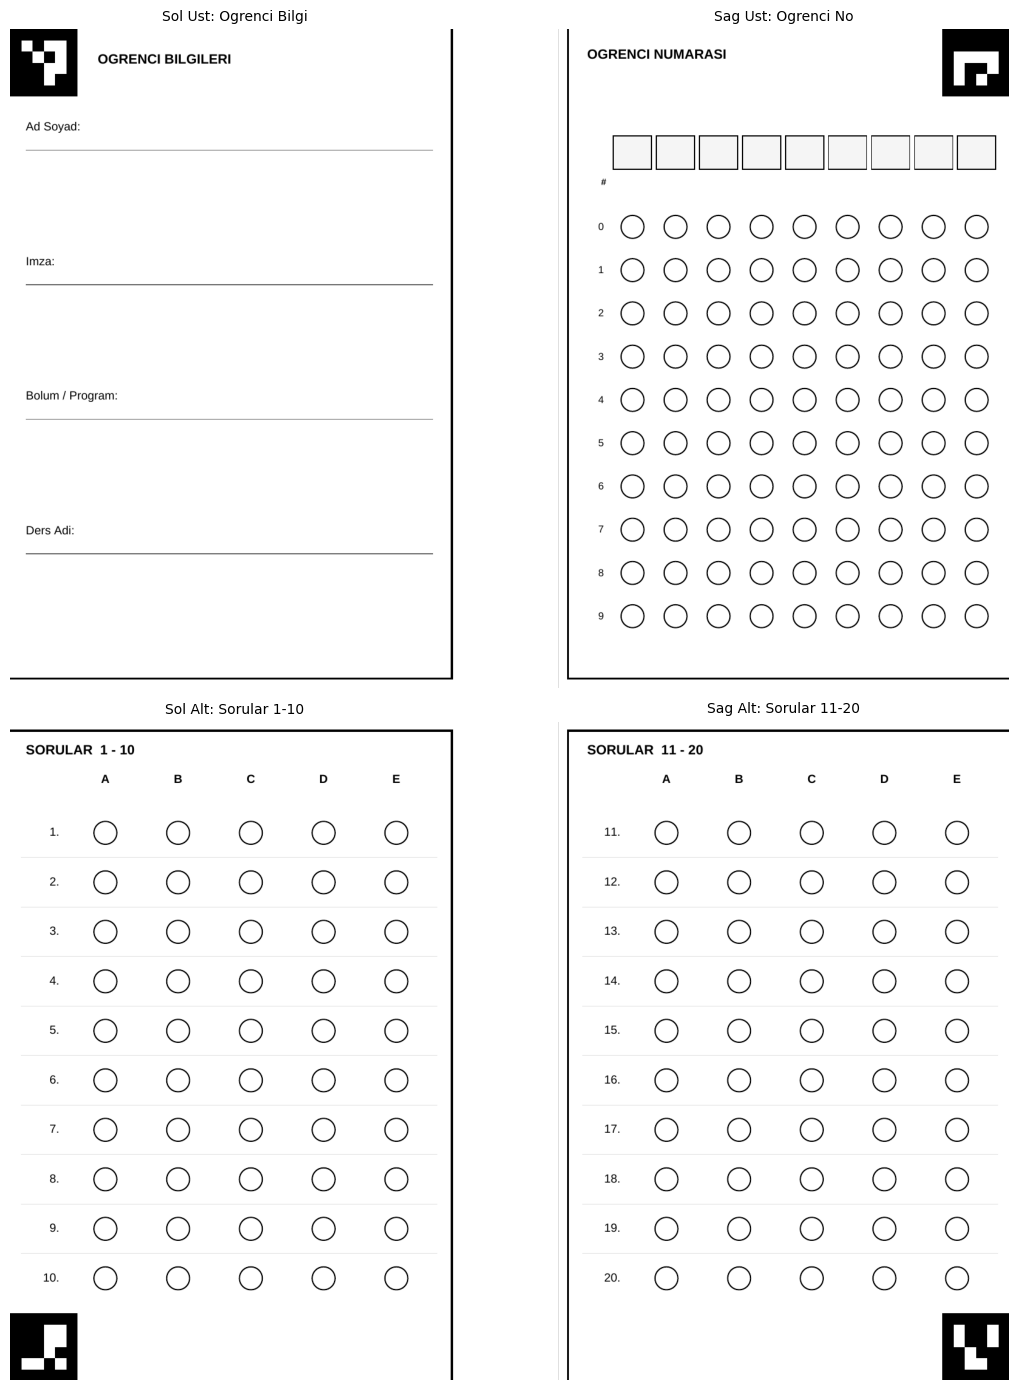


--- OKUMA BASARILI ---
Ogrenci No : ?????????

Soru   Cevap      Anahtar    Sonuc
----------------------------------------
  1    BOS        A          BOS
  2    BOS        C          BOS
  3    BOS        B          BOS
  4    BOS        D          BOS
  5    BOS        E          BOS
  6    BOS        A          BOS
  7    BOS        B          BOS
  8    BOS        C          BOS
  9    BOS        D          BOS
  10   BOS        A          BOS
  11   BOS        B          BOS
  12   BOS        E          BOS
  13   BOS        C          BOS
  14   BOS        A          BOS
  15   BOS        D          BOS
  16   BOS        C          BOS
  17   BOS        B          BOS
  18   BOS        E          BOS
  19   BOS        A          BOS
  20   BOS        D          BOS

Dogru:0  Yanlis:0  Bos:20  Puan:0/100


In [5]:
# HUCRE 3 — TEK SAYFA TEST
# Bu hucreyi calistirinca 'Dosya Sec' butonu cikacaktir.

CEVAP_ANAHTARI = {
     1:'A',  2:'C',  3:'B',  4:'D',  5:'E',
     6:'A',  7:'B',  8:'C',  9:'D', 10:'A',
    11:'B', 12:'E', 13:'C', 14:'A', 15:'D',
    16:'C', 17:'B', 18:'E', 19:'A', 20:'D'
}

print('1. ADIM: Test kagidini yukleyin (PDF veya JPG)...')
yuklenen = files.upload()

if not yuklenen:
    print('Dosya yuklenmedi, islem durduruldu.')
else:
    test_dosya = list(yuklenen.keys())[0]
    print(f'Dosya alindi: {test_dosya}')

    if test_dosya.lower().endswith('.pdf'):
        print('PDF goruntuye donusturuluyor...')
        sayfalar = convert_from_path(f'/content/{test_dosya}', dpi=TARAMA_DPI)
        test_img = sayfalar[0]
    else:
        test_img = Image.open(f'/content/{test_dosya}')

    print('2. ADIM: Gemini API ve Marker analizi basladi (30-60 sn surebilir)...')
    sonuc = kagit_oku(test_img, CEVAP_ANAHTARI, sayfa_no=1, debug=True)
#sonuc = kagit_oku(test_img, CEVAP_ANAHTARI, sayfa_no=1, debug=False)
    if sonuc.get('hata'):
        print(f'\n!!! HATA OLISTU: {sonuc["hata"]}')
    else:
        print(f'\n--- OKUMA BASARILI ---')
        print(f'Ogrenci No : {sonuc["ogrenci_no"]}')
        print(f'\n{"Soru":<6} {"Cevap":<10} {"Anahtar":<10} {"Sonuc"}')
        print("-"*40)
        for s in range(1, 21):
            c = sonuc['cevaplar'].get(s, '?')
            a = CEVAP_ANAHTARI.get(s, '?')
            if c == a:        simge = 'DOGRU'
            elif c == 'BOS':  simge = 'BOS'
            elif c == 'HATA': simge = 'HATA'
            elif '/' in c:    simge = 'COKLU'   # ← bu satır eksikti
            else:             simge = 'YANLIS'
            print(f'  {s:<4} {c:<10} {a:<10} {simge}')

        print(f'\nDogru:{sonuc["dogru"]}  Yanlis:{sonuc["yanlis"]}  '
              f'Bos:{sonuc["bos"]}  Puan:{sonuc["puan"]}/100')

In [10]:
# HUCRE 4 — TOPLU OKUMA + CSV

# ── Cevap anahtarini buraya gir ──────────────────────────────
CEVAP_ANAHTARI = {
     1:'A',  2:'C',  3:'B',  4:'D',  5:'E',
     6:'A',  7:'B',  8:'C',  9:'D', 10:'A',
    11:'B', 12:'E', 13:'C', 14:'A', 15:'D',
    16:'C', 17:'B', 18:'E', 19:'A', 20:'D'
}

# ── PDF yukle ────────────────────────────────────────────────
print('Sinav PDF dosyasini yukle (tum kagitlar tek PDF):')
yuklenen  = files.upload()
sinav_pdf = list(yuklenen.keys())[0]
print(f'Yuklendi: {sinav_pdf}')

print('PDF sayfalara bolunuyor...')
sayfalar = convert_from_path(f'/content/{sinav_pdf}', dpi=TARAMA_DPI)
toplam   = len(sayfalar)
print(f'{toplam} sayfa bulundu\n')

# ── Toplu oku ────────────────────────────────────────────────
tum_sonuclar = []
hatalar      = []

for i, sayfa in enumerate(sayfalar, 1):
    if i > 1:
        time.sleep(1)  # Rate limit icin bekle
    sonuc = kagit_oku(sayfa, CEVAP_ANAHTARI, sayfa_no=i)
    tum_sonuclar.append(sonuc)
    if sonuc.get('hata'):
        hatalar.append(f'Sayfa {i}: {sonuc["hata"]}')
        print(f'  Sayfa {i:3d}/{toplam}  HATA: {sonuc["hata"]}')
    else:
        print(f'  Sayfa {i:3d}/{toplam}  '
              f'No:{sonuc["ogrenci_no"]}  '
              f'D:{sonuc["dogru"]} Y:{sonuc["yanlis"]} B:{sonuc["bos"]}  '
              f'Puan:{sonuc["puan"]}')

# ── CSV kaydet ───────────────────────────────────────────────
csv_yolu = '/content/sinav_sonuclari.csv'
sutunlar = (['sayfa','ogrenci_no'] +
            [f'S{i}' for i in range(1,21)] +
            ['dogru','yanlis','bos','puan','hata'])

with open(csv_yolu, 'w', newline='', encoding='utf-8-sig') as f:
    yazar = csv.writer(f)
    yazar.writerow(sutunlar)
    for s in tum_sonuclar:
        satir = ([s.get('sayfa',''), s.get('ogrenci_no','')] +
                 [s['cevaplar'].get(i,'?') for i in range(1,21)] +
                 [s.get('dogru',''), s.get('yanlis',''),
                  s.get('bos',''),   s.get('puan',''), s.get('hata','')])
        yazar.writerow(satir)

# ── Ozet rapor ───────────────────────────────────────────────
print(f'\n{"="*50}')
print(f'  OZET RAPOR')
print(f'{"="*50}')
print(f'  Toplam kagit    : {toplam}')
print(f'  Basarili okunan : {toplam - len(hatalar)}')
print(f'  Hata            : {len(hatalar)}')

basarili = [s for s in tum_sonuclar if not s.get('hata')]
if basarili:
    puanlar = [s['puan'] for s in basarili]
    print(f'\n  En yuksek puan  : {max(puanlar)}')
    print(f'  En dusuk puan   : {min(puanlar)}')
    print(f'  Sinif ortalamasi: {round(sum(puanlar)/len(puanlar), 1)}')

if hatalar:
    print(f'\n  Hatali sayfalar:')
    for h in hatalar:
        print(f'    {h}')

print(f'{"="*50}')

# ── CSV indir ────────────────────────────────────────────────
files.download(csv_yolu)
print('\nsinav_sonuclari.csv indirildi!')

Sinav PDF dosyasini yukle (tum kagitlar tek PDF):


Saving img20260316_15473230.pdf to img20260316_15473230 (1).pdf
Yuklendi: img20260316_15473230 (1).pdf
PDF sayfalara bolunuyor...
1 sayfa bulundu

  Sayfa   1/1  No:251232109  D:5 Y:15 B:0  Puan:25

  OZET RAPOR
  Toplam kagit    : 1
  Basarili okunan : 1
  Hata            : 0

  En yuksek puan  : 25
  En dusuk puan   : 25
  Sinif ortalamasi: 25.0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


sinav_sonuclari.csv indirildi!


In [ ]:
# API durumu test et
resp = requests.post(GEMINI_URL,
    json={'contents': [{'parts': [{'text': 'merhaba'}]}]},
    timeout=10)
print(resp.status_code)
print(resp.json())

429
{'error': {'code': 429, 'message': 'Your project has exceeded its spending cap.', 'status': 'RESOURCE_EXHAUSTED'}}


In [ ]:
# HUCRE 5 — WEB ARAYUZU OLUSTUR (app.py)
# Bu hucre web arayuzunu /content/omr_sistem/app.py dosyasina yazar

app_kodu = 'import streamlit as st\nimport sqlite3, bcrypt, json, os, base64, time, tempfile\nimport cv2, numpy as np, requests\nimport pandas as pd\nfrom pdf2image import convert_from_path\nfrom PIL import Image\nfrom openpyxl import Workbook\nfrom openpyxl.styles import Font, PatternFill, Alignment, Border, Side\nfrom io import BytesIO\n\n# ─── AYARLAR ────────────────────────────────────────────────\nTARAMA_DPI     = 300\nMAX_GORUNTU_PX = 1200\nDB_YOLU        = "/content/omr_sistem/omr.db"\n\nARUCO_DICT   = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)\nARUCO_PARAMS = cv2.aruco.DetectorParameters()\nARUCO_DETEK  = cv2.aruco.ArucoDetector(ARUCO_DICT, ARUCO_PARAMS)\n\n# ─── VERİTABANI ─────────────────────────────────────────────\ndef db_bag():\n    return sqlite3.connect(DB_YOLU)\n\ndef db_olustur():\n    con = db_bag()\n    con.executescript(\n        "CREATE TABLE IF NOT EXISTS kullanicilar ("\n        "id INTEGER PRIMARY KEY AUTOINCREMENT,"\n        "kullanici_adi TEXT UNIQUE NOT NULL,"\n        "sifre_hash TEXT NOT NULL,"\n        "tam_ad TEXT);"\n        "CREATE TABLE IF NOT EXISTS sablonlar ("\n        "id INTEGER PRIMARY KEY AUTOINCREMENT,"\n        "kullanici_id INTEGER,"\n        "ad TEXT NOT NULL,"\n        "soru_sayisi INTEGER DEFAULT 20,"\n        "tarih TIMESTAMP DEFAULT CURRENT_TIMESTAMP);"\n        "CREATE TABLE IF NOT EXISTS cevap_anahtarlari ("\n        "id INTEGER PRIMARY KEY AUTOINCREMENT,"\n        "kullanici_id INTEGER,"\n        "sablon_id INTEGER,"\n        "ad TEXT NOT NULL,"\n        "cevaplar TEXT NOT NULL,"\n        "tarih TIMESTAMP DEFAULT CURRENT_TIMESTAMP);"\n        "CREATE TABLE IF NOT EXISTS ogrenci_listeleri ("\n        "id INTEGER PRIMARY KEY AUTOINCREMENT,"\n        "kullanici_id INTEGER,"\n        "ad TEXT NOT NULL,"\n        "ogrenciler TEXT NOT NULL,"\n        "tarih TIMESTAMP DEFAULT CURRENT_TIMESTAMP);"\n    )\n    sifre = bcrypt.hashpw(b"admin123", bcrypt.gensalt()).decode()\n    con.execute("INSERT OR IGNORE INTO kullanicilar (kullanici_adi,sifre_hash,tam_ad) VALUES (?,?,?)",\n                ("admin", sifre, "Yonetici"))\n    con.commit()\n    con.close()\n\n# ─── GİRİŞ ──────────────────────────────────────────────────\ndef giris_kontrol(adi, sifre):\n    con = db_bag()\n    satir = con.execute("SELECT id,sifre_hash,tam_ad FROM kullanicilar WHERE kullanici_adi=?", (adi,)).fetchone()\n    con.close()\n    if satir and bcrypt.checkpw(sifre.encode(), satir[1].encode()):\n        return {"id": satir[0], "kullanici_adi": adi, "tam_ad": satir[2]}\n    return None\n\ndef giris_sayfasi():\n    st.markdown("""\n    <style>\n    .ana{text-align:center;color:#1a56db;font-size:2.5rem;font-weight:800;margin-top:3rem;}\n    .alt{text-align:center;color:#6b7280;margin-bottom:2rem;}\n    </style>\n    <div class="ana">📋 OMR Sinav Sistemi</div>\n    <div class="alt">Optik Isaretleme Okuyucu</div>\n    """, unsafe_allow_html=True)\n    _, orta, _ = st.columns([1,2,1])\n    with orta:\n        with st.container(border=True):\n            st.subheader("Giris Yap")\n            adi   = st.text_input("Kullanici Adi")\n            sifre = st.text_input("Sifre", type="password")\n            if st.button("Giris Yap", use_container_width=True, type="primary"):\n                k = giris_kontrol(adi, sifre)\n                if k:\n                    st.session_state.kullanici = k\n                    st.rerun()\n                else:\n                    st.error("Kullanici adi veya sifre hatali!")\n            st.caption("Varsayilan: admin / admin123")\n\n# ─── OMR YARDIMCI FONKSİYONLAR ──────────────────────────────\ndef pil_to_cv(img):\n    return cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)\n\ndef b64_yap(cv_img):\n    h, w = cv_img.shape[:2]\n    if max(h,w) > MAX_GORUNTU_PX:\n        oran = MAX_GORUNTU_PX / max(h,w)\n        cv_img = cv2.resize(cv_img, (int(w*oran), int(h*oran)))\n    _, buf = cv2.imencode(".jpg", cv_img, [cv2.IMWRITE_JPEG_QUALITY, 90])\n    return base64.b64encode(buf).decode()\n\ndef aruco_tespit(cv_img):\n    gri = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)\n    corners, ids, _ = ARUCO_DETEK.detectMarkers(gri)\n    if ids is None or len(ids) < 4:\n        return None\n    m = {}\n    for i, mid in enumerate(ids.flatten()):\n        if mid in [0,1,2,3]:\n            m[int(mid)] = corners[i][0]\n    return m if len(m) == 4 else None\n\ndef bolgeleri_ayir(cv_img, m):\n    dk = {0:m[0][0], 1:m[1][1], 2:m[2][3], 3:m[3][2]}\n    xl = int(dk[0][0]); xr = int(dk[1][0])\n    yt = int(dk[0][1]); yb = int(dk[2][1])\n    xm = int((xl+xr)/2); ym = int((yt+yb)/2)\n    return {\n        0: cv_img[yt:ym, xl:xm],\n        1: cv_img[yt:ym, xm:xr],\n        2: cv_img[ym:yb, xl:xm],\n        3: cv_img[ym:yb, xm:xr],\n    }\n\ndef gemini_cagir_web(cv_img, prompt, api_key):\n    url  = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent?key={api_key}"\n    body = {\n        "contents": [{"parts": [\n            {"text": prompt},\n            {"inline_data": {"mime_type": "image/jpeg", "data": b64_yap(cv_img)}}\n        ]}],\n        "generationConfig": {"temperature": 0, "thinkingConfig": {"thinkingBudget": 1024}}\n    }\n    for d in range(3):\n        try:\n            r = requests.post(url, json=body, timeout=30)\n            if r.status_code == 429:\n                time.sleep(10); continue\n            r.raise_for_status()\n            metin = r.json()["candidates"][0]["content"]["parts"][0]["text"].strip()\n            if "```" in metin:\n                for p in metin.split("```"):\n                    p = p.strip()\n                    if p.startswith("json"): p = p[4:].strip()\n                    if p.startswith("{"): metin = p.strip(); break\n            if "{" in metin and "}" in metin:\n                metin = metin[metin.index("{"):metin.rindex("}")+1]\n            return json.loads(metin)\n        except Exception as e:\n            if d < 2: time.sleep(2)\n            else: return {"hata": str(e)}\n\nPROMPT_NO = (\n    "Bu goruntude bir ogrenci numarasi balon tablosu var.\\n"\n    "9 SUTUN (soldan saga 1-9. hane), 10 SATIR (0-9 rakamlari).\\n"\n    "Her sutunda YALNIZCA BIR balon dolu olmalidir.\\n"\n    "Her sutunu BAGIMSIZ degerlendirip EN KOYU balonu bul.\\n"\n    "Bos balon = sadece ince cember, ici beyaz.\\n"\n    "Yanlis okuma yapma, dikkatli incele.\\n"\n    \'SADECE JSON don: {"no": "123456789"}\'\n)\n\ndef cevap_prompt(bas, bit):\n    return (\n        f"Bu goruntude {bas}-{bit} sorularinin cevap balonlari var.\\n"\n        "Her satir bir soru, satirda A B C D E siklari var.\\n"\n        "Her satiri BAGIMSIZ degerlendirip EN KOYU balonu bul.\\n"\n        "Birden fazla esit koyulukta balon varsa hepsini yaz (ornegin \\"A/C\\").\\n"\n        "Hic dolu balon yoksa \\"BOS\\" yaz.\\n"\n        f"SADECE JSON don: {{\\"{bas}\\": \\"A\\", ..., \\"{bit}\\": \\"C\\"}}"\n    )\n\ndef bilgi_prompt():\n    return (\n        "Bu goruntude ogrenci bilgi formu var.\\n"\n        "Ad Soyad, Bolum/Program ve Ders Adi alanlarini oku. El yazisi olabilir.\\n"\n        "SADECE JSON don: {\\"ad_soyad\\": \\"Ad Soyad\\", \\"bolum\\": \\"Bolum\\", \\"ders\\": \\"Ders\\"}"\n    )\n\ndef kagit_oku_web(pil_img, cevap_anahtari, api_key, soru_sayisi=20):\n    cv_img    = pil_to_cv(pil_img)\n    markerlar = aruco_tespit(cv_img)\n    if markerlar is None:\n        return None, "ArUco marker bulunamadi"\n    bolgeler = bolgeleri_ayir(cv_img, markerlar)\n    bilgi    = gemini_cagir_web(bolgeler[0], bilgi_prompt(), api_key)\n    ad_soyad = bilgi.get("ad_soyad","?") if isinstance(bilgi,dict) and "hata" not in bilgi else "?"\n    h, w  = bolgeler[1].shape[:2]\n    buyuk = cv2.resize(bolgeler[1], (int(w*1.5), int(h*1.5)), interpolation=cv2.INTER_CUBIC)\n    no_s  = gemini_cagir_web(buyuk, PROMPT_NO, api_key)\n    no    = str(no_s.get("no","?????????")) if isinstance(no_s,dict) and "hata" not in no_s else "?????????"\n    no    = no[:9].ljust(9,"?")\n    cevaplar = {}\n    orta = soru_sayisi // 2\n    c1   = gemini_cagir_web(bolgeler[2], cevap_prompt(1, orta), api_key)\n    c2   = gemini_cagir_web(bolgeler[3], cevap_prompt(orta+1, soru_sayisi), api_key)\n    if isinstance(c1,dict) and "hata" not in c1:\n        cevaplar.update({int(k):str(v).upper() for k,v in c1.items() if str(k).isdigit()})\n    if isinstance(c2,dict) and "hata" not in c2:\n        cevaplar.update({int(k):str(v).upper() for k,v in c2.items() if str(k).isdigit()})\n    dogru  = sum(1 for s in range(1,soru_sayisi+1) if cevaplar.get(s)==cevap_anahtari.get(s))\n    yanlis = sum(1 for s in range(1,soru_sayisi+1)\n                 if cevaplar.get(s) not in (cevap_anahtari.get(s),"BOS","HATA")\n                 and "/" not in str(cevaplar.get(s,"")))\n    bos  = sum(1 for s in range(1,soru_sayisi+1) if cevaplar.get(s)=="BOS")\n    puan = round(dogru * (100/soru_sayisi), 2)\n    return {"ad_soyad":ad_soyad,"ogrenci_no":no,"cevaplar":cevaplar,\n            "dogru":dogru,"yanlis":yanlis,"bos":bos,"puan":puan}, None\n\n# ─── EXCEL ──────────────────────────────────────────────────\ndef excel_ozet(sonuclar):\n    wb = Workbook(); ws = wb.active; ws.title = "Ozet"\n    mavi  = PatternFill("solid", fgColor="1a56db")\n    beyaz = Font(color="FFFFFF", bold=True)\n    kenar = Border(left=Side(style="thin"),right=Side(style="thin"),\n                   top=Side(style="thin"),bottom=Side(style="thin"))\n    for j,b in enumerate(["Sayfa","Ad Soyad","Ogrenci No","Durum","Dogru","Yanlis","Bos","Puan"],1):\n        h = ws.cell(row=1,column=j,value=b)\n        h.fill=mavi; h.font=beyaz; h.alignment=Alignment(horizontal="center"); h.border=kenar\n    for i,s in enumerate(sonuclar,2):\n        for j,d in enumerate([s.get("sayfa"),s.get("ad_soyad"),s.get("ogrenci_no"),\n                               s.get("durum"),s.get("dogru"),s.get("yanlis"),\n                               s.get("bos"),s.get("puan")],1):\n            hc = ws.cell(row=i,column=j,value=d)\n            hc.border=kenar; hc.alignment=Alignment(horizontal="center")\n            durum = s.get("durum","")\n            if "Eslesme var" in durum: hc.fill=PatternFill("solid",fgColor="d1fae5")\n            elif "farkli" in durum:    hc.fill=PatternFill("solid",fgColor="fef3c7")\n            elif "yok" in durum:       hc.fill=PatternFill("solid",fgColor="fee2e2")\n    for col in ws.columns:\n        ws.column_dimensions[col[0].column_letter].width=18\n    buf = BytesIO(); wb.save(buf); return buf.getvalue()\n\ndef excel_detay(sonuclar, cevap_anahtari, soru_sayisi=20):\n    wb = Workbook(); ws = wb.active; ws.title = "Detay"\n    mavi  = PatternFill("solid",fgColor="1a56db")\n    beyaz = Font(color="FFFFFF",bold=True)\n    kenar = Border(left=Side(style="thin"),right=Side(style="thin"),\n                   top=Side(style="thin"),bottom=Side(style="thin"))\n    basliklar = ["Ad Soyad","Ogrenci No"] + [f"S{i}" for i in range(1,soru_sayisi+1)]\n    for j,b in enumerate(basliklar,1):\n        h = ws.cell(row=1,column=j,value=b)\n        h.fill=mavi; h.font=beyaz; h.alignment=Alignment(horizontal="center"); h.border=kenar\n    ws.cell(row=2,column=1,value="CEVAP ANAHTARI").font=Font(bold=True)\n    ws.cell(row=2,column=2,value="-")\n    for s in range(1,soru_sayisi+1):\n        hc = ws.cell(row=2,column=s+2,value=cevap_anahtari.get(s,"?"))\n        hc.fill=PatternFill("solid",fgColor="dbeafe")\n        hc.font=Font(bold=True); hc.alignment=Alignment(horizontal="center"); hc.border=kenar\n    for i,s in enumerate(sonuclar,3):\n        ws.cell(row=i,column=1,value=s.get("ad_soyad","")).border=kenar\n        ws.cell(row=i,column=2,value=s.get("ogrenci_no","")).border=kenar\n        for soru in range(1,soru_sayisi+1):\n            c  = s.get("cevaplar",{}).get(soru,"?")\n            a  = cevap_anahtari.get(soru,"?")\n            hc = ws.cell(row=i,column=soru+2,value=c)\n            hc.alignment=Alignment(horizontal="center"); hc.border=kenar\n            if c==a:       hc.fill=PatternFill("solid",fgColor="d1fae5")\n            elif c=="BOS": hc.fill=PatternFill("solid",fgColor="f3f4f6")\n            else:          hc.fill=PatternFill("solid",fgColor="fee2e2")\n    for col in ws.columns:\n        ws.column_dimensions[col[0].column_letter].width=12\n    buf = BytesIO(); wb.save(buf); return buf.getvalue()\n\n# ─── SAYFALAR ───────────────────────────────────────────────\ndef sayfa_sablon():\n    st.header("Sablon Yonetimi")\n    uid = st.session_state.kullanici["id"]\n    with st.container(border=True):\n        st.subheader("Yeni Sablon Ekle")\n        adi = st.text_input("Sablon Adi")\n        ss  = st.selectbox("Soru Sayisi", [10,20,30,40,50], index=1)\n        if st.button("Kaydet", type="primary"):\n            if adi:\n                con = db_bag()\n                con.execute("INSERT INTO sablonlar (kullanici_id,ad,soru_sayisi) VALUES (?,?,?)",(uid,adi,ss))\n                con.commit(); con.close()\n                st.success(f"\'{adi}\' kaydedildi!"); st.rerun()\n            else: st.warning("Sablon adi girin!")\n    st.subheader("Kayitli Sablonlar")\n    con = db_bag()\n    rows = con.execute("SELECT id,ad,soru_sayisi,tarih FROM sablonlar WHERE kullanici_id=? ORDER BY id DESC",(uid,)).fetchall()\n    con.close()\n    if rows:\n        for r in rows:\n            c1,c2,c3,c4 = st.columns([3,2,3,1])\n            c1.write(f"**{r[1]}**"); c2.write(f"{r[2]} soru"); c3.write(r[3][:16])\n            if c4.button("Sil",key=f"ds{r[0]}"):\n                con2=db_bag(); con2.execute("DELETE FROM sablonlar WHERE id=?",(r[0],)); con2.commit(); con2.close(); st.rerun()\n    else: st.info("Henuz sablon yok.")\n\ndef sayfa_anahtar():\n    st.header("Cevap Anahtari")\n    uid = st.session_state.kullanici["id"]\n    con = db_bag()\n    sablonlar = con.execute("SELECT id,ad,soru_sayisi FROM sablonlar WHERE kullanici_id=?",(uid,)).fetchall()\n    con.close()\n    if not sablonlar: st.warning("Once sablon ekleyin!"); return\n    sablon = st.selectbox("Sablon Sec", sablonlar, format_func=lambda x: f"{x[1]} ({x[2]} soru)")\n    ss     = sablon[2]\n    adi    = st.text_input("Cevap Anahtari Adi (orn: Vize 2025)")\n    st.subheader("Cevaplari Sec")\n    cevaplar = {}\n    for i in range(0, ss, 5):\n        cols = st.columns(5)\n        for j,col in enumerate(cols):\n            sno = i+j+1\n            if sno <= ss:\n                with col:\n                    cevaplar[sno] = st.selectbox(f"Soru {sno}",["A","B","C","D","E"],key=f"ca{sno}")\n    if st.button("Anahtari Kaydet", type="primary"):\n        if adi:\n            con = db_bag()\n            con.execute("INSERT INTO cevap_anahtarlari (kullanici_id,sablon_id,ad,cevaplar) VALUES (?,?,?,?)",\n                        (uid,sablon[0],adi,json.dumps(cevaplar)))\n            con.commit(); con.close()\n            st.success(f"\'{adi}\' kaydedildi!")\n        else: st.warning("Cevap anahtari adi girin!")\n    st.subheader("Kayitli Anahtarlar")\n    con = db_bag()\n    rows = con.execute("SELECT id,ad,tarih FROM cevap_anahtarlari WHERE kullanici_id=? ORDER BY id DESC",(uid,)).fetchall()\n    con.close()\n    for r in rows:\n        c1,c2,c3 = st.columns([4,3,1])\n        c1.write(f"**{r[1]}**"); c2.write(r[2][:16])\n        if c3.button("Sil",key=f"da{r[0]}"):\n            con2=db_bag(); con2.execute("DELETE FROM cevap_anahtarlari WHERE id=?",(r[0],)); con2.commit(); con2.close(); st.rerun()\n\ndef sayfa_liste():\n    st.header("Ogrenci Listesi")\n    uid = st.session_state.kullanici["id"]\n    with st.container(border=True):\n        st.subheader("Excel Yukle")\n        st.caption("A sutunu = Ogrenci No | B sutunu = Ad Soyad")\n        adi      = st.text_input("Liste Adi")\n        yuklenen = st.file_uploader("Excel Dosyasi", type=["xlsx","xls"])\n        if yuklenen and adi and st.button("Listeyi Kaydet", type="primary"):\n            df = pd.read_excel(yuklened, header=None)\n            ogrenciler = [{"no":str(r[0]).strip(),"ad":str(r[1]).strip()} for _,r in df.iterrows()]\n            con = db_bag()\n            con.execute("INSERT INTO ogrenci_listeleri (kullanici_id,ad,ogrenciler) VALUES (?,?,?)",\n                        (uid,adi,json.dumps(ogrenciler,ensure_ascii=False)))\n            con.commit(); con.close()\n            st.success(f"{len(ogrenciler)} ogrenci kaydedildi!"); st.rerun()\n    st.subheader("Kayitli Listeler")\n    con = db_bag()\n    rows = con.execute("SELECT id,ad,ogrenciler,tarih FROM ogrenci_listeleri WHERE kullanici_id=? ORDER BY id DESC",(uid,)).fetchall()\n    con.close()\n    for r in rows:\n        og = json.loads(r[2])\n        c1,c2,c3,c4 = st.columns([3,2,3,1])\n        c1.write(f"**{r[1]}**"); c2.write(f"{len(og)} ogrenci"); c3.write(r[3][:16])\n        if c4.button("Sil",key=f"dl{r[0]}"):\n            con2=db_bag(); con2.execute("DELETE FROM ogrenci_listeleri WHERE id=?",(r[0],)); con2.commit(); con2.close(); st.rerun()\n\ndef sayfa_sinav():\n    st.header("Sinav Oku")\n    uid = st.session_state.kullanici["id"]\n    con = db_bag()\n    sablonlar  = con.execute("SELECT id,ad,soru_sayisi FROM sablonlar WHERE kullanici_id=?",(uid,)).fetchall()\n    anahtarlar = con.execute("SELECT id,ad,sablon_id,cevaplar FROM cevap_anahtarlari WHERE kullanici_id=?",(uid,)).fetchall()\n    listeler   = con.execute("SELECT id,ad,ogrenciler FROM ogrenci_listeleri WHERE kullanici_id=?",(uid,)).fetchall()\n    con.close()\n    if not sablonlar or not anahtarlar:\n        st.warning("Once sablon ve cevap anahtari ekleyin!"); return\n    c1,c2 = st.columns(2)\n    with c1:\n        sablon  = st.selectbox("Sablon", sablonlar, format_func=lambda x: f"{x[1]} ({x[2]} soru)")\n        anahtar = st.selectbox("Cevap Anahtari", anahtarlar, format_func=lambda x: x[1])\n    with c2:\n        liste   = st.selectbox("Ogrenci Listesi (opsiyonel)", [None]+list(listeler),\n                               format_func=lambda x: "Secme" if x is None else x[1])\n        api_key = st.text_input("Gemini API Key", type="password")\n    pdf = st.file_uploader("Sinav PDF", type=["pdf"])\n    if pdf and api_key and st.button("Sinavi Oku", type="primary", use_container_width=True):\n        anahtardict = {int(k):v for k,v in json.loads(anahtar[3]).items()}\n        ss          = sablon[2]\n        og_dict     = {}\n        if liste:\n            og_dict = {o["no"]:o["ad"] for o in json.loads(liste[2])}\n        with tempfile.NamedTemporaryFile(suffix=".pdf", delete=False) as f:\n            f.write(pdf.read()); tmp = f.name\n        sayfalar = convert_from_path(tmp, dpi=TARAMA_DPI)\n        toplam   = len(sayfalar)\n        st.write(f"**{toplam} sayfa bulundu**")\n        prog     = st.progress(0)\n        durum    = st.empty()\n        sonuclar = []\n        for i,sayfa in enumerate(sayfalar,1):\n            if i > 1: time.sleep(1)\n            durum.write(f"Sayfa {i}/{toplam} okunuyor...")\n            s, hata = kagit_oku_web(sayfa, anahtardict, api_key, ss)\n            if hata:\n                sonuclar.append({"sayfa":i,"hata":hata,"durum":"Hata",\n                                  "ad_soyad":"?","ogrenci_no":"?","dogru":0,\n                                  "yanlis":0,"bos":ss,"puan":0,"cevaplar":{}})\n            else:\n                d = "Liste secilmedi"\n                if og_dict:\n                    no_e     = s["ogrenci_no"] in og_dict\n                    liste_ad = og_dict.get(s["ogrenci_no"],"").lower()\n                    ad_e     = any(p in liste_ad for p in s["ad_soyad"].lower().split() if len(p)>2)\n                    if no_e and ad_e:  d = "Eslesme var"\n                    elif no_e:         d = "No eslesti, ad farkli"\n                    elif ad_e:         d = "Ad eslesti, no farkli"\n                    else:              d = "Eslesme yok"\n                s["sayfa"] = i; s["durum"] = d\n                sonuclar.append(s)\n            prog.progress(i/toplam)\n        durum.empty()\n        st.session_state.sonuclar    = sonuclar\n        st.session_state.anahtardict = anahtardict\n        st.session_state.ss          = ss\n        st.success(f"{toplam} kagit okundu!"); st.rerun()\n    if "sonuclar" in st.session_state:\n        sonuclar    = st.session_state.sonuclar\n        anahtardict = st.session_state.anahtardict\n        ss          = st.session_state.ss\n        st.subheader("Sonuclar")\n        df_data = [{"Sayfa":s.get("sayfa"),"Ad Soyad":s.get("ad_soyad"),\n                    "No":s.get("ogrenci_no"),"Durum":s.get("durum"),\n                    "Dogru":s.get("dogru"),"Yanlis":s.get("yanlis"),\n                    "Puan":s.get("puan")} for s in sonuclar]\n        st.dataframe(pd.DataFrame(df_data), use_container_width=True)\n        c1,c2 = st.columns(2)\n        with c1:\n            st.download_button("Ozet Excel Indir", excel_ozet(sonuclar),\n                               "ozet.xlsx","application/vnd.openxmlformats-officedocument.spreadsheetml.sheet",\n                               use_container_width=True)\n        with c2:\n            st.download_button("Detay Excel Indir", excel_detay(sonuclar,anahtardict,ss),\n                               "detay.xlsx","application/vnd.openxmlformats-officedocument.spreadsheetml.sheet",\n                               use_container_width=True)\n\ndef sayfa_kullanici():\n    st.header("Kullanici Yonetimi")\n    uid  = st.session_state.kullanici["id"]\n    kadi = st.session_state.kullanici["kullanici_adi"]\n    with st.container(border=True):\n        st.subheader("Yeni Kullanici Ekle")\n        yadi = st.text_input("Kullanici Adi")\n        ytam = st.text_input("Ad Soyad")\n        ysif = st.text_input("Sifre", type="password")\n        if st.button("Kullanici Ekle", type="primary"):\n            if yadi and ysif:\n                try:\n                    sh = bcrypt.hashpw(ysif.encode(),bcrypt.gensalt()).decode()\n                    con = db_bag()\n                    con.execute("INSERT INTO kullanicilar (kullanici_adi,sifre_hash,tam_ad) VALUES (?,?,?)",(yadi,sh,ytam))\n                    con.commit(); con.close()\n                    st.success(f"\'{yadi}\' eklendi!")\n                except: st.error("Bu kullanici adi zaten var!")\n            else: st.warning("Kullanici adi ve sifre gerekli!")\n    with st.container(border=True):\n        st.subheader("Sifre Degistir")\n        eski = st.text_input("Mevcut Sifre", type="password")\n        yeni = st.text_input("Yeni Sifre", type="password")\n        if st.button("Sifreyi Degistir"):\n            if giris_kontrol(kadi, eski):\n                sh = bcrypt.hashpw(yeni.encode(),bcrypt.gensalt()).decode()\n                con = db_bag()\n                con.execute("UPDATE kullanicilar SET sifre_hash=? WHERE id=?",(sh,uid))\n                con.commit(); con.close()\n                st.success("Sifre degistirildi!")\n            else: st.error("Mevcut sifre hatali!")\n\n# ─── ANA UYGULAMA ────────────────────────────────────────────\nst.set_page_config(page_title="OMR Sinav Sistemi", page_icon="📋",\n                   layout="wide", initial_sidebar_state="expanded")\ndb_olustur()\n\nif "kullanici" not in st.session_state:\n    giris_sayfasi()\nelse:\n    k = st.session_state.kullanici\n    with st.sidebar:\n        st.markdown(f"### {k[\'tam_ad\'] or k[\'kullanici_adi\']}")\n        st.divider()\n        sayfa = st.radio("Menu",[\n            "Sablon Yonetimi",\n            "Cevap Anahtari",\n            "Ogrenci Listesi",\n            "Sinav Oku",\n            "Kullanici Yonetimi",\n        ])\n        st.divider()\n        if st.button("Cikis Yap"):\n            del st.session_state.kullanici\n            st.rerun()\n\n    if   sayfa == "Sablon Yonetimi":    sayfa_sablon()\n    elif sayfa == "Cevap Anahtari":     sayfa_anahtar()\n    elif sayfa == "Ogrenci Listesi":    sayfa_liste()\n    elif sayfa == "Sinav Oku":          sayfa_sinav()\n    elif sayfa == "Kullanici Yonetimi": sayfa_kullanici()\n'

with open('/content/omr_sistem/app.py', 'w', encoding='utf-8') as f:
    f.write(app_kodu)
print('Web arayuzu dosyasi olusturuldu: /content/omr_sistem/app.py')

In [ ]:
# HUCRE 6 — WEB SISTEMINI BASLAT
#
# ONCE: https://dashboard.ngrok.com adresine gidip ucretsiz hesap ac
# Sonra: Sol menuden 'Your Authtoken' kismindaki token'i kopyala
# Asagiya yapistir:

from pyngrok import ngrok
import subprocess, time

NGROK_TOKEN = 'BURAYA_NGROK_TOKEN_YAPISTIR'
ngrok.set_auth_token(NGROK_TOKEN)

# Onceki streamlit varsa kapat
import os
os.system('pkill -f streamlit')
time.sleep(2)

proc = subprocess.Popen(
    ['streamlit', 'run', '/content/omr_sistem/app.py',
     '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(4)

tunnel = ngrok.connect(8501)
print('=' * 55)
print('  OMR SISTEM HAZIR!')
print(f'  URL: {tunnel.public_url}')
print('=' * 55)
print('  Kullanici adi : admin')
print('  Sifre         : admin123')
print('=' * 55)
print()
print('NOT: Mevcut Colab hucreleri (1-4) hala calisir!')
print('     Sadece web arayuzu icin 5 ve 6. hucreler eklendi.')